<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Building a Variational Quantum Model

_Prepared by Claudia Zendejas-Morales_

This notebook closes the section by assembling the three design blocks already introduced: feature map, ansatz, and readout. The goal is to make the forward model explicit, so that the variational QML pipeline is already well defined before Section 3 introduces optimization and evaluation.


## From circuit blocks to a model function

A variational quantum model begins with a classical sample $\vec{x}^{\,j} \in \mathbb{R}^d$. The feature map prepares

$$
|\psi_{\mathrm{in}}(\vec{x}^{\,j})\rangle = U_F(\vec{x}^{\,j})|0\rangle^{\otimes n}
$$

the ansatz transforms that state into

$$
|\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})\rangle = U_A(\boldsymbol{\theta})|\psi_{\mathrm{in}}(\vec{x}^{\,j})\rangle
$$

and the readout extracts one or more classical quantities. In the most general form used in this tutorial, a measured feature vector can be written as

$$
\mathbf{m}(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\bigl(\langle O_1 \rangle, \langle O_2 \rangle, \dots, \langle O_R \rangle\bigr)
$$

and the final prediction is obtained by a classical post-processing map

$$
\hat y(\vec{x}^{\,j}, \boldsymbol{\theta}) = g\!\left(\mathbf{m}(\vec{x}^{\,j}, \boldsymbol{\theta})\right)
$$

Here $g$ denotes the final classical post-processing rule applied to the measured quantum features. Depending on the task, $g$ may be as simple as a sign rule, an affine map for regression, or a small classical head acting on a measured feature vector.

A scalar-observable model is a special case, where $R=1$ and

$$
\hat y(\vec{x}^{\,j}, \boldsymbol{\theta}) = g\!\left(\langle O \rangle\right)
$$


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>State, measured features, and prediction are different objects</b><br>
The quantum state $|\psi_{\mathrm{out}}\rangle$ is not yet the model prediction. The measured features $\mathbf{m}$ are not yet the loss either. A variational QML model only becomes a usable predictive function after the circuit output is mapped into a classical quantity with a clear task meaning.
</div>


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/variational-model-forward-pass.png" alt="Variational QML forward pass with classical post-processing" width="800"/>
</p>

This version of the pipeline makes the final classical post-processing step explicit: the quantum circuit produces measured features, and the prediction appears only after the classical map $g$ acts on those features.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Scope of this notebook</b><br>
This notebook focuses on variational quantum models (VQMs). They are one of the most common and well-established approaches in QML, but they are not the only possible QML paradigm. Many ideas from this section, especially data encoding, also appear in other QML paradigms such as quantum kernel methods.
</div>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp, state_fidelity

import pennylane as qml


## A small forward pass on a toy dataset

We now build a complete forward model on a tiny two-feature dataset. The point is not to train it yet, but to make the object “a variational model” concrete in code.


0: ─╭AngleEmbedding(M0)─╭●──RY(0.60)──╭●─┤  <Z>
1: ─╰AngleEmbedding(M0)─╰X──RY(-0.35)─╰X─┤     

M0 = 
[0.2 0.3]

sample            score      predicted label    reference label
[0.2 0.3]     0.776          +1                +1
[0.35 1.  ]     0.612          +1                +1
[1.1  0.25]     0.250          +1                -1
[1.25 1.1 ]    -0.217          -1                -1


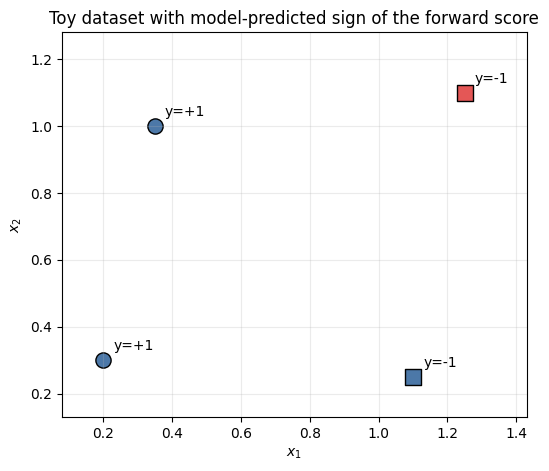

In [2]:
X_toy = np.array([
    [0.20, 0.30],
    [0.35, 1.00],
    [1.10, 0.25],
    [1.25, 1.10],
])
y_toy = np.array([+1, +1, -1, -1])

weights = np.array([0.60, -0.35])
threshold = 0.0

dev_model = qml.device("default.qubit", wires=2)

@qml.qnode(dev_model)
def scalar_model(sample, weights):
    # Feature map
    qml.AngleEmbedding(sample, wires=[0, 1], rotation="Y")

    # Ansatz
    qml.CNOT(wires=[0, 1])
    qml.RY(weights[0], wires=0)
    qml.RY(weights[1], wires=1)
    qml.CNOT(wires=[0, 1])

    # Scalar readout
    return qml.expval(qml.PauliZ(0))

def forward_score(sample, weights):
    return float(scalar_model(sample, weights))

def predict_label(sample, weights, threshold=0.0):
    # Final decision rule
    score = forward_score(sample, weights)
    return +1 if score >= threshold else -1

print(qml.draw(scalar_model)(X_toy[0], weights))
print()
print("sample            score      predicted label    reference label")
for sample, target in zip(X_toy, y_toy):
    score = forward_score(sample, weights)
    label = predict_label(sample, weights, threshold=threshold)
    print(f"{sample}   {score:7.3f}          {label:+d}                {target:+d}")

plt.figure(figsize=(6, 5))
colors = ["#4c78a8" if predict_label(sample, weights, threshold) > 0 else "#e45756" for sample in X_toy]
for sample, target, color in zip(X_toy, y_toy, colors):
    marker = "o" if target > 0 else "s"
    plt.scatter(sample[0], sample[1], s=120, c=color, marker=marker, edgecolor="black")
    plt.text(sample[0] + 0.03, sample[1] + 0.03, f"y={target:+d}", fontsize=10)
plt.xlim(X_toy[:, 0].min() - 0.12, X_toy[:, 0].max() + 0.18)
plt.ylim(X_toy[:, 1].min() - 0.12, X_toy[:, 1].max() + 0.18)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Toy dataset with model-predicted sign of the forward score")
plt.grid(alpha=0.25)
plt.show()


This example already contains the essential anatomy of a variational model: feature map, ansatz, scalar readout, and a final decision rule. The weights are fixed by hand, so the circuit is **not trained**. Still, the forward pass is already well defined: each sample is mapped to one real score, and that score is mapped to a predicted label.

In the plot, the **color** represents the model's predicted label from the sign of the forward score: blue means the model predicts $+1$, while red means the model predicts $-1$. The text labels `y=+1` and `y=-1` indicate the **reference target labels** assigned to the toy samples, so they let us compare the fixed model output against the intended task labels. The marker shape also follows the reference label: circles correspond to target $+1$ and squares correspond to target $-1$. This makes the figure a compact visual check of whether the hand-chosen forward model is already aligned, at least roughly, with the label structure of the toy dataset before any training begins.

### Task 1 (coding): Rebuild the same forward model in Qiskit

Using Qiskit, reproduce the same two-qubit forward model on the sample set

```python
samples_task = np.array([
    [0.10, 0.45],
    [0.55, 0.95],
    [1.00, 0.20],
    [1.30, 1.00],
])
```

with the same variational parameters `weights = np.array([0.60, -0.35])`.

Your implementation should:

- build the same circuit skeleton used in the PennyLane example;
- compute the exact scalar score $\langle Z_0 \rangle$ with `Statevector` and `SparsePauliOp`;
- produce predicted labels for both thresholds `0.0` and `0.25`;
- identify which samples change label when the threshold changes.

Official references that may help:

- <a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/2.0/qiskit.quantum_info.Statevector"><code>Statevector</code></a>
- <a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/2.0/qiskit.quantum_info.SparsePauliOp"><code>SparsePauliOp</code></a>


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 1 solution:</b> <a href="05-building-a-variational-quantum-model-solutions.ipynb#task1-solution">Click here for Task 1 solution</a>
</div>


In [3]:
# Task 1 starter
samples_task = np.array([
    [0.10, 0.45],
    [0.55, 0.95],
    [1.00, 0.20],
    [1.30, 1.00],
])
weights = np.array([0.60, -0.35])
thresholds = [0.0, 0.25]

def qiskit_forward_circuit(sample, weights):
    # TODO: build the same circuit skeleton used in the PennyLane example
    pass

def qiskit_forward_score(sample, weights):
    # TODO: return the exact value of <Z0> with Statevector and SparsePauliOp
    pass

def predict_label_from_score(score, threshold=0.0):
    # TODO: map the scalar score to a label in {-1, +1}
    pass

# TODO:
# 1. evaluate the exact score for each sample
# 2. compute labels for thresholds 0.0 and 0.25
# 3. identify which samples change label when the threshold changes
# 4. explain what changed and why


## The same state-preparation skeleton can support different outputs

Once the feature map and ansatz are fixed, the same state-preparation block can be interpreted in several ways. For the same $|\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})\rangle$, one may define

$$
\hat y_{\mathrm{cls}}(\vec{x}^{\,j}, \boldsymbol{\theta}) = \operatorname{sign}(\langle Z_0 \rangle)
$$

$$
\hat y_{\mathrm{reg}}(\vec{x}^{\,j}, \boldsymbol{\theta}) = a + b\,\langle Z_0 \rangle
$$

or a kernel-like similarity score between two samples

$$
k_{\boldsymbol{\theta}}(\vec{x}^{\,j}, \vec{x}^{\,j'}) = \left|\langle \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) | \psi_{\mathrm{out}}(\vec{x}^{\,j'}, \boldsymbol{\theta}) \rangle\right|^2
$$

The state-preparation skeleton is the same in all three cases. What changes is how the resulting state is interpreted and what kind of classical quantity is extracted from it.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Kernel-like similarity is not yet a trained predictor</b><br>
A kernel-like similarity score such as $k_{\boldsymbol{\theta}}(\vec{x}^{\,j}, \vec{x}^{\,j'})$ can be useful, but by itself it is not yet a classifier or regressor. Later sections will return to kernel methods more carefully. Here the point is only that the same state-preparation block can support different task semantics.
</div>


sample            classification score   class label   regression output
[0.2 0.3]        0.776            +1             1.821
[0.45 0.85]        0.559            +1             1.647
[1.2  0.35]        0.119            +1             1.295


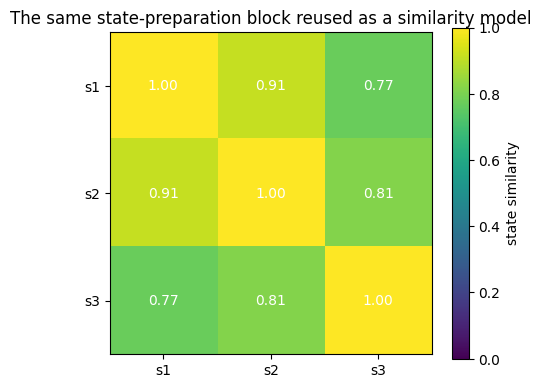

In [4]:
dev_state = qml.device("default.qubit", wires=2)

@qml.qnode(dev_state)
def prepared_state(sample, weights):
    qml.AngleEmbedding(sample, wires=[0, 1], rotation="Y")
    qml.CNOT(wires=[0, 1])
    qml.RY(weights[0], wires=0)
    qml.RY(weights[1], wires=1)
    qml.CNOT(wires=[0, 1])
    return qml.state()

def classification_output(sample, weights):
    score = forward_score(sample, weights)
    return score, (+1 if score >= 0 else -1)

def regression_output(sample, weights, a=1.2, b=0.8):
    return a + b * forward_score(sample, weights)

def similarity_output(sample_a, sample_b, weights):
    state_a = prepared_state(sample_a, weights)
    state_b = prepared_state(sample_b, weights)
    return float(qml.math.fidelity_statevector(state_a, state_b))

samples_compare = [
    np.array([0.20, 0.30]),
    np.array([0.45, 0.85]),
    np.array([1.20, 0.35]),
]

print("sample            classification score   class label   regression output")
for sample in samples_compare:
    score, label = classification_output(sample, weights)
    reg = regression_output(sample, weights, a=1.2, b=0.8)
    print(f"{sample}      {score:7.3f}            {label:+d}           {reg:7.3f}")

sim_matrix = np.zeros((len(samples_compare), len(samples_compare)))
for a in range(len(samples_compare)):
    for b in range(len(samples_compare)):
        sim_matrix[a, b] = similarity_output(samples_compare[a], samples_compare[b], weights)

plt.figure(figsize=(5.2, 4.3))
plt.imshow(sim_matrix, vmin=0.0, vmax=1.0, cmap='viridis')
plt.xticks(range(len(samples_compare)), [f"s{i+1}" for i in range(len(samples_compare))])
plt.yticks(range(len(samples_compare)), [f"s{i+1}" for i in range(len(samples_compare))])
plt.colorbar(label='state similarity')
plt.title('The same state-preparation block reused as a similarity model')
for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        plt.text(j, i, f"{sim_matrix[i, j]:.2f}", ha='center', va='center', color='white')
plt.show()


The classification score, the regression output, and the similarity matrix come from the same state-preparation circuit family. In this example all three samples receive the label $+1$ because their scalar scores $\langle Z_0 \rangle$ remain positive, but the regression output still separates them by magnitude through the affine map $a + b\,\langle Z_0 \rangle$.

The similarity matrix answers a different question: how close the prepared quantum states are to one another. Its diagonal entries are exactly $1$ because each state is perfectly similar to itself, and the matrix is symmetric because similarity is the same in both directions. The largest off-diagonal entry is the pair $(s_1, s_2)$, so those two samples are the closest under this state-preparation model, while $(s_1, s_3)$ is the least similar pair in this example. The heatmap colors encode the same values numerically: brighter cells indicate higher state similarity, and darker cells indicate lower similarity.

That is the structural point of this notebook: before training starts, one must already know what quantity the model is supposed to produce.


### Task 2 (coding): Use the same Qiskit state-preparation model for three output semantics

Using the same circuit skeleton as in the example above, work on the sample set

```python
samples_task = np.array([
    np.array([0.18, 0.22]),
    np.array([0.60, 0.70]),
    np.array([1.05, 0.30]),
    np.array([1.35, 0.95]),
])
```

with `weights = np.array([0.45, -0.20])`.

Your task is to compute all three of the following from the same state-preparation model:

- the classification score $\langle Z_0 \rangle$ and the corresponding sign label;
- a regression output of the form `0.5 + 1.1 * <Z0>`;
- the full pairwise similarity matrix based on state fidelity.

Then answer two short questions:

- Which pair of samples is most similar under the state-preparation model?
- Do the samples with the most similar states necessarily receive similar scalar outputs under the classification or regression readout?

Official references that may help:

- <a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/2.0/qiskit.quantum_info.Statevector"><code>Statevector</code></a>
- <a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/2.0/qiskit.quantum_info.SparsePauliOp"><code>SparsePauliOp</code></a>
- <a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/2.0/qiskit.quantum_info.state_fidelity"><code>state_fidelity</code></a>


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 2 solution:</b> <a href="05-building-a-variational-quantum-model-solutions.ipynb#task2-solution">Click here for Task 2 solution</a>
</div>


In [5]:
# Task 2 starter
samples_task = np.array([
    np.array([0.18, 0.22]),
    np.array([0.60, 0.70]),
    np.array([1.05, 0.30]),
    np.array([1.35, 0.95]),
])
weights = np.array([0.45, -0.20])
Z0_OP = SparsePauliOp.from_list([("IZ", 1.0)])

def qiskit_state_prep_circuit(sample, weights):
    # TODO: build the same circuit skeleton used in the example above with QuantumCircuit
    pass

def prepared_state_task(sample, weights):
    # TODO: return Statevector.from_instruction(qiskit_state_prep_circuit(sample, weights))
    pass

def classification_score_task(sample, weights):
    # TODO: use SparsePauliOp and expectation_value to return the scalar score <Z0>
    pass

def regression_output_task(sample, weights):
    # TODO: return 0.5 + 1.1 * <Z0>
    pass

# TODO:
# 1. compute classification score and sign label for each sample
# 2. compute the regression output for each sample
# 3. build the full pairwise similarity matrix with state_fidelity
# 4. identify the most similar pair and compare that with the scalar outputs


## Before training: a model-design checklist

Before introducing loss functions or optimizers, it is worth checking that the forward model is internally coherent. A practical checklist is:

- **Input compatibility**: Is the feature dimension $d$ consistent with the chosen encoding and the available qubit count $n$?
- **Ansatz budget**: Is the circuit depth reasonable for simulation cost and future hardware constraints?
- **Readout meaning**: Does the chosen observable or measured feature vector actually match the task semantics?
- **Output range**: Is the prediction already in the right scale for labels or targets, or will a classical map be required?
- **Shot sensitivity**: If the model later runs with sampled measurements, is the chosen output stable enough to estimate efficiently?
- **Evaluation fairness**: Is there a classical baseline and a leakage-safe preprocessing pipeline ready for comparison?

A model that fails one of these checks can be difficult to interpret even before training begins.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Training starts only after model semantics are fixed</b><br>
Section 3 will introduce losses, optimization, and evaluation. But optimization only makes sense once the model already has a clear input representation, a clear state-preparation block, and a clear interpretation of its output.
</div>


### Task 3 (design): Specify a coherent variational model before training

For each scenario below, propose a coherent model specification by choosing:

- one encoding strategy;
- one ansatz family;
- one readout rule;
- one short justification for why the output meaning matches the task.

Scenario A:
- Two real-valued features are available.
- Only two qubits are available.
- The target is binary classification.
- A shallow circuit is preferred.

Scenario B:
- Four real-valued features are available.
- The target is a real number in a bounded interval.
- You want a scalar output that is easy to interpret before training.
- Simulation is available, but future shot cost should still be kept in mind.

Scenario C:
- You are not yet interested in a final class label.
- What matters first is whether pairs of samples are mapped to similar or dissimilar quantum states.
- Later sections will study kernel methods more explicitly.

For each scenario, explain in about 5 to 7 sentences what model you would build and why.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 3 solution:</b> <a href="05-building-a-variational-quantum-model-solutions.ipynb#task3-solution">Click here for Task 3 solution</a>
</div>


## Closing remarks

A variational quantum model is not only a circuit. It is a full forward map from classical input to classical output, and that map only becomes well defined when the feature map, ansatz, and readout are specified together.

The next section will keep this model fixed and study what it means to train it: how losses are defined, how gradients or gradient-free updates are obtained, and how performance is evaluated on data.
